# Lab 4: Control P/PID en TempLAB UdeA

## Objetivo
- Evaluar el desempeño de un controlador **P-only**.
- Obtener parámetros críticos para sintonía **Ziegler-Nichols**.
- Implementar y comparar el desempeño de **PID** frente a **P-only**.

## Flujo del notebook
1. Cargar y visualizar datos de P-only.
2. Estimar período de oscilación $P_u$.
3. Calcular parámetros PID (ITAE y ZN).
4. Comparar métricas de desempeño.
5. Registrar conclusiones experimentales.

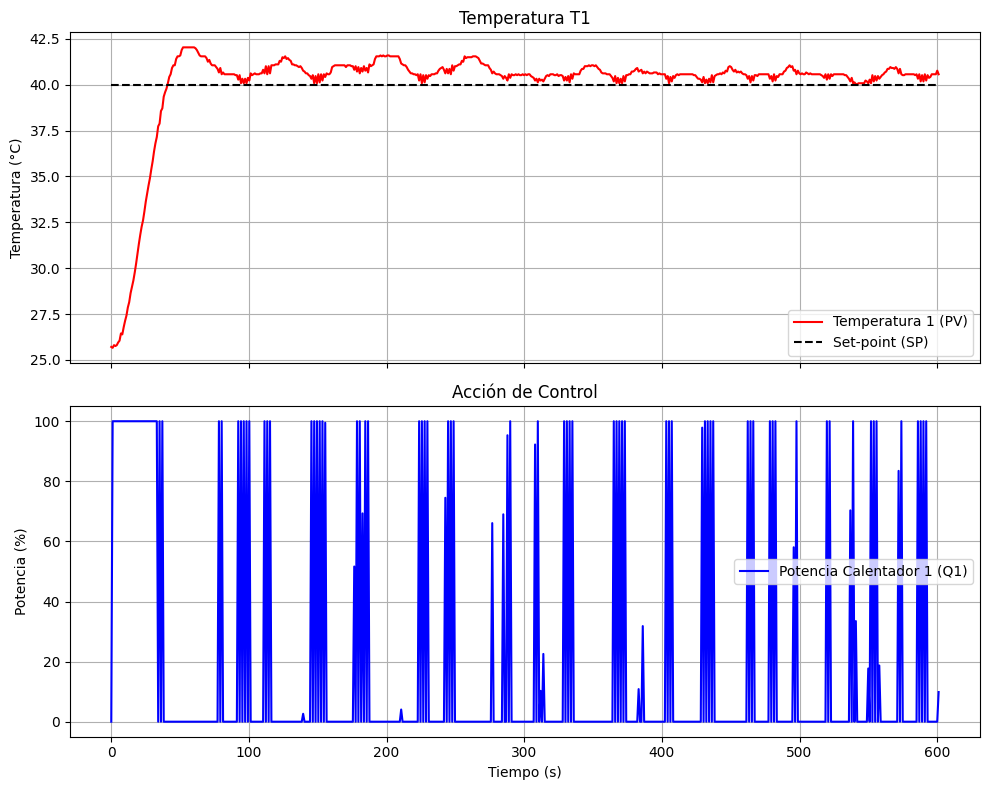

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def cargar_datos(path):
    """Carga datos y adapta columnas para formatos de 4 o 7 columnas."""
    data = np.loadtxt(path, delimiter=',', skiprows=1, encoding='latin1')

    if data.shape[1] == 4:
        # Tiempo_s,Cal1_pct,Temp1_C,Set1_C
        t = data[:, 0]
        q1 = data[:, 1]
        t1 = data[:, 2]
        sp1 = data[:, 3]
    elif data.shape[1] >= 6:
        # Formato antiguo: Tiempo,Q1,Q2,T1,T2,SP1,SP2
        t = data[:, 0]
        q1 = data[:, 1]
        t1 = data[:, 3]
        sp1 = data[:, 5]
    else:
        raise ValueError("Formato de archivo no reconocido")

    return t, q1, t1, sp1


# Cambia el nombre del archivo según tu corrida
archivo = 'data_ponly_kc500.txt'

try:
    tiempo, q1, t1, sp1 = cargar_datos(archivo)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(tiempo, t1, 'r-', linewidth=2, label='Temperatura T1 (PV)')
    ax1.plot(tiempo, sp1, 'k--', linewidth=2, label='Setpoint (SP)')
    ax1.set_ylabel('Temperatura (°C)')
    ax1.set_title('Respuesta del proceso (P-only)')
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.plot(tiempo, q1, 'b-', linewidth=2, label='Q1 (%)')
    ax2.set_xlabel('Tiempo (s)')
    ax2.set_ylabel('Potencia (%)')
    ax2.set_title('Señal de control')
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('analisis_control_P.png', dpi=150, bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print(f"No se encontró el archivo: {archivo}")
except Exception as e:
    print(f"Error al procesar datos: {e}")

## 1) Control P-only

### Ecuación usada

$$u(t)=Q_{bias}+K_c\,e(t),\quad e(t)=T_{SP}-T_{PV}(t)$$

En esta sección se analiza la respuesta de temperatura y la señal de control para cuantificar el **offset**.

### Corrida sugerida en terminal

```bash
python3 lab4.py --sim --mode p --tuning itae --kc-factor 1.0 --min 6.2
```

También probar: `--kc-factor 0.5 0.8 1.2 1.5` y guardar cada archivo con nombre distinto.

## 2) Identificación de $P_u$ y $K_u$ (Ziegler-Nichols)

### Procedimiento ZN
1. Ejecutar P-only aumentando $K_c$ hasta oscilación sostenida.
2. Medir:
   - $K_u$: ganancia crítica
   - $P_u$: período de oscilación

### Fórmulas PID (ZN)

$$K_p = 0.6K_u,\quad T_i = 0.5P_u,\quad T_d = 0.125P_u$$

## 3) Cálculo y ajuste de parámetros PID

Número de picos detectados: 11
Periodo de oscilación calculado (Pu): 43.84 segundos


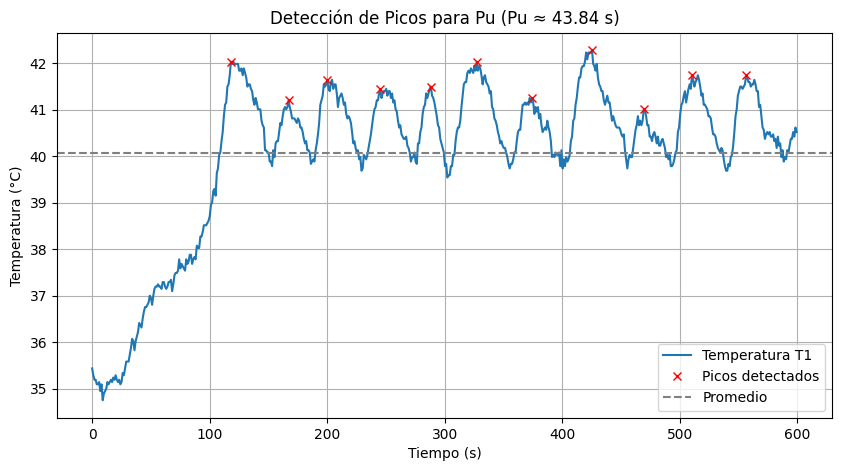

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


def cargar_datos(path):
    data = np.loadtxt(path, delimiter=',', skiprows=1, encoding='latin1')
    if data.shape[1] == 4:
        t = data[:, 0]
        t1 = data[:, 2]
        sp1 = data[:, 3]
    else:
        t = data[:, 0]
        t1 = data[:, 3]
        sp1 = data[:, 5]
    return t, t1, sp1


def calcular_metricas(t, y, sp, tol=0.05):
    e = sp - y
    sp_ref = np.mean(sp)

    y_max = np.max(y)
    sobreimp = max(0.0, (y_max - sp_ref) / sp_ref * 100.0) if sp_ref != 0 else np.nan

    banda = tol * sp_ref
    dentro = np.abs(e) <= banda
    t_settle = np.nan
    if np.any(dentro):
        idx = np.argmax(dentro)
        t_settle = t[idx]

    n = len(e)
    e_ss = np.mean(e[int(0.8*n):])

    dt = np.diff(t, prepend=t[0])
    iae = np.sum(np.abs(e) * dt)
    ise = np.sum((e**2) * dt)

    return {
        'Sobreimpulso_%': sobreimp,
        'T_asentamiento_s': t_settle,
        'Error_estado_est_C': e_ss,
        'IAE': iae,
        'ISE': ise,
    }


archivo = 'data_ponly_kc500.txt'

try:
    t, y, sp = cargar_datos(archivo)

    # Ignora arranque para detectar oscilación sostenida
    idx0 = np.argmax(t > 60)
    t_det = t[idx0:]
    y_det = y[idx0:]

    picos, _ = find_peaks(y_det, distance=40, prominence=0.2)
    t_picos = t_det[picos]
    y_picos = y_det[picos]

    if len(t_picos) >= 2:
        periodos = np.diff(t_picos)
        Pu = np.mean(periodos)
        print(f"Pu estimado: {Pu:.2f} s")
    else:
        Pu = np.nan
        print("No se detectaron suficientes picos para estimar Pu")

    met = calcular_metricas(t, y, sp)
    print("\nMétricas P-only")
    for k, v in met.items():
        print(f"{k}: {v:.4f}" if isinstance(v, (int, float, np.floating)) else f"{k}: {v}")

    plt.figure(figsize=(12, 5))
    plt.plot(t, y, label='T1 (PV)', linewidth=2)
    plt.plot(t, sp, '--', label='SP', linewidth=2)
    if len(t_picos) > 0:
        plt.plot(t_picos, y_picos, 'rx', ms=8, mew=2, label='Picos')
    plt.title('Detección de oscilación para estimar Pu')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Temperatura (°C)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"No se encontró el archivo: {archivo}")
except Exception as e:
    print(f"Error: {e}")

## 4) Parámetros finales y ejecución PID

Usa los valores medidos de $K_u$ y $P_u$ para correr PID en terminal:

```bash
python3 lab4.py --sim --mode pid --tuning zn --ku <Ku> --pu <Pu> --kc-factor 1.0 --min 6.2
```

Repetir con `kc-factor = 0.5, 0.8, 1.2, 1.5` para comparación.

## 5) Cálculo de parámetros PID (plantilla)

Completar con tus valores experimentales:
- $K_u = $ ...
- $P_u = $ ...

$$K_p = 0.6K_u,\quad T_i = 0.5P_u,\quad T_d = 0.125P_u$$

In [ ]:
# Plantilla final para cálculo de parámetros PID

Ku = 0.35   # Reemplaza con tu valor medido
Pu = 85.0   # Reemplaza con tu valor medido (s)

Kp = 0.6 * Ku
Ti = 0.5 * Pu
Td = 0.125 * Pu

print('Parámetros PID (Ziegler-Nichols)')
print(f'Ku = {Ku:.4f}')
print(f'Pu = {Pu:.4f} s')
print(f'Kp = {Kp:.4f}')
print(f'Ti = {Ti:.4f} s')
print(f'Td = {Td:.4f} s')

print('\nBarrido recomendado de Kc:')
for f in [0.5, 0.8, 1.0, 1.2, 1.5]:
    print(f'kc-factor={f:.1f}  ->  Kc={Kp*f:.4f}')